### 순열

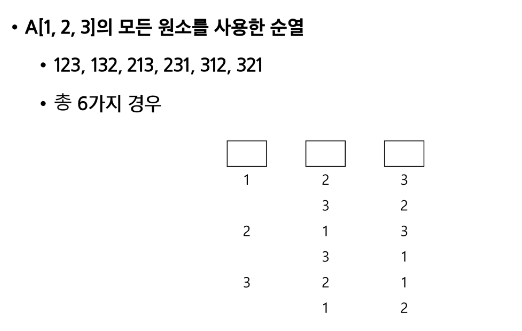

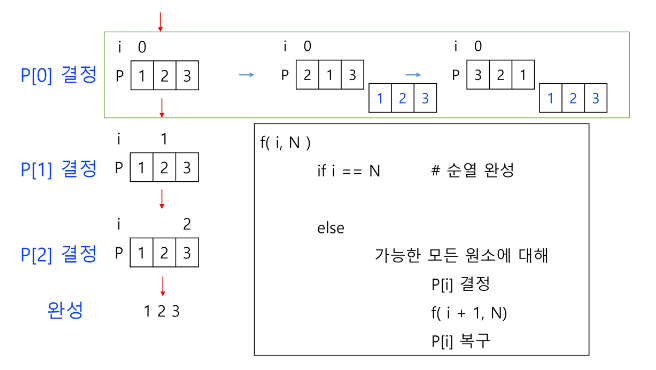

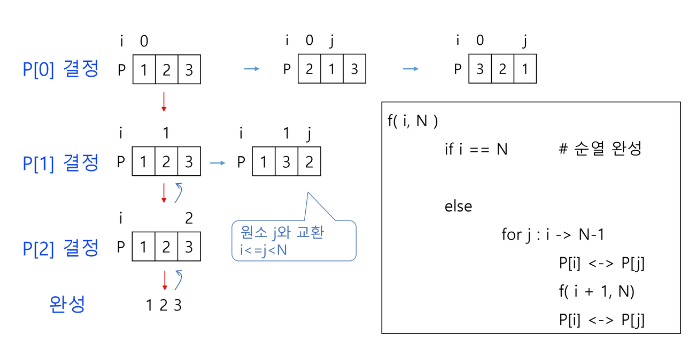

In [1]:
def f(i, k):
    if i==k:
        print(*P)
    else:
        for j in range(i, k):    # P[i] 자리에 올 원소 P[j]
            P[i], P[j] = P[j], P[i]                 # P[i] <-> P[j]
            f(i+1, k)
            P[i], P[j] = P[j], P[i]    # 교환 전으로 복구

N = 3
P = [1,2,3]
f(0, N)  # 0부터 시작, 총 개수는 N

1 2 3
1 3 2
2 1 3
2 3 1
3 2 1
3 1 2


In [ ]:
"""
NxN 배열의 숫자중 한 줄에 하나씩 N개의 숫자를 골라 합이 최소

"""
def f(i, k):
    global cnt
    global min_v
    cnt += 1
    if i==k:
        # print(*P)
        s = 0    # 선택한 원소의 합
        for j in range(k):    # j행에 대해
            s += arr[j][P[j]]   # j행에서 P[j]열을 고른 경우의 합 구하기
            if min_v > s:
                min_v = s  
    else:
        for j in range(i, k):    # P[i] 자리에 올 원소 P[j]
            P[i], P[j] = P[j], P[i]                 # P[i] <-> P[j]
            f(i+1, k)
            P[i], P[j] = P[j], P[i]    # 교환 전으로 복구

N = int(input())
arr = [list(map(int, input().split())) for _ in range(N)]
P = [i for i in range(N)]
min_v = 100
cnt = 0
f(0, N)  # 0부터 시작, 총 개수는 N
print(min_v)

In [2]:
"""
같은 코드지만 이게 더 짧고 빠름
백트래킹은 재귀를 이용한 완전탐색
이를 활용하여 가지를 쳐서 시간을 줄일 수 있음
완전탐색과 백트래킹을 활용하여 순열을 구하고, 
각 순열에 대해 특정 조건을 만족하는 경우의 수를 계산

i: 현재 순열에서의 인덱스 또는 위치를 나타냅니다.
k: 순열의 총 원소 개수를 나타냅니다.
s: 현재까지의 순열 원소 합을 나타냅니다.
"""
def f(i, k, s):     # i-1까지 선택한
    global cnt
    global min_v
    cnt += 1
    if i==k:    # 모든 원소를 선택한 경우
        # print(*P)
        if min_v > s:
            min_v = s  
    
    elif s >= min_v:   # 현재까지의 합이 이미 찾은 최소값보다 크거나 같으면 종료
        return

    else:
        for j in range(i, k):    # P[i] 자리에 올 원소 P[j]
            P[i], P[j] = P[j], P[i]                 # P[i] <-> P[j]
#재귀적으로 다음 위치로 이동하고, 현재까지의 합에 새로 추가된 원소의 값을 더해줍니다.
            f(i+1, k, s+arr[i][P[i]])
            P[i], P[j] = P[j], P[i]    # 교환 전으로 복구

N = int(input())
arr = [list(map(int, input().split())) for _ in range(N)]
P = [i for i in range(N)] # [0, 1, 2]
min_v = 100
cnt = 0
f(0, N, 0)  # 0부터 시작, 총 개수는 N
print(min_v, cnt)